In [1]:
import sqlite3
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import numpy as np

DB = '../data/humans_clean.sqlite3'
conn = sqlite3.connect(DB)
conn.execute('PRAGMA cache_size=-500000')

# Find interesting polities with enough politicians
rows = conn.execute('''
    SELECT ic.polity_name, COUNT(DISTINCT ic.wikidata_id) as n,
           MIN(ic.impact_date) as yr_min, MAX(ic.impact_date) as yr_max
    FROM individuals_cliopatria ic
    JOIN individuals i ON ic.wikidata_id = i.wikidata_id
    WHERE i.occupations_en LIKE '%politician%'
      AND ic.impact_date IS NOT NULL
    GROUP BY ic.polity_name
    HAVING n >= 100
    ORDER BY n DESC
''').fetchall()

for r in rows[:30]:
    print(f"{r[0]:50s}  n={r[1]:>6d}  ({r[2]}–{r[3]})")

United States of America;(United States of America)  n= 84678  (1776–2024)
French Fifth Republic                               n= 58416  (1958–2024)
Republic of Indonesia                               n= 38251  (1946–2024)
(British Empire);Kingdom of Great Britain           n= 23541  (1709–1999)
Union of Soviet Socialist Republics                 n= 19471  (1922–1991)
Republic of Finland                                 n= 14499  (1918–2024)
People's Republic of China                          n= 12068  (1950–2024)
German Democratic Republic                          n= 11931  (1949–1990)
Republic of India                                   n= 11349  (1947–2024)
Republic of Italy                                   n= 10844  (1946–2024)
(Kingdom of Spain);Kingdom of Spain                 n= 10211  (1525–2024)
(Netherlands);Netherlands                           n= 10145  (1815–2024)
(British Empire);British Colonial Empire            n= 10092  (1713–1999)
Ming Dynasty                         

In [2]:
# Get polity periods from the database
periods = conn.execute('''
    SELECT DISTINCT polity_name, from_year, to_year
    FROM cliopatria_polity_periods
    ORDER BY polity_name, from_year
''').fetchall()
polity_periods = defaultdict(list)
for name, fr, to in periods:
    polity_periods[name].append((fr, to))

# Polities with clear rise-and-collapse arcs
selected = [
    ('Ming Dynasty',
     "ic.polity_name LIKE '%Ming%dynasty%' OR ic.polity_name LIKE '%Ming Dynasty%'"),
    ('Qing Dynasty',
     "ic.polity_name LIKE '%Qing%dynasty%' OR ic.polity_name LIKE '%Qing Dynasty%'"),
    ('Russian Empire',
     "ic.polity_name = 'Russian Empire'"),
    ('German Empire',
     "ic.polity_name = 'German Empire'"),
    ('Austria-Hungary',
     "ic.polity_name = 'Austria-Hungary'"),
    ('Empire of Japan',
     "ic.polity_name LIKE '%Empire of Japan%'"),
]

for label, where in selected:
    n = conn.execute(f'''
        SELECT COUNT(DISTINCT ic.wikidata_id)
        FROM individuals_cliopatria ic
        JOIN individuals i ON ic.wikidata_id = i.wikidata_id
        WHERE ({where}) AND i.occupations_en LIKE '%politician%' AND ic.impact_date IS NOT NULL
    ''').fetchone()[0]
    plist = polity_periods.get(label, [])
    period_str = f"{plist[0][0]}–{plist[-1][1]}" if plist else "?"
    print(f"{label:30s}  n={n:>5d}  period={period_str}")

Ming Dynasty                    n= 9677  period=1375–1644


Qing Dynasty                    n= 3767  period=1645–1911


Russian Empire                  n= 5956  period=1721–1916


German Empire                   n= 7843  period=1871–1919


Austria-Hungary                 n= 7222  period=1868–1918


Empire of Japan                 n= 8352  period=1868–1945


In [3]:
# Build data: % of politicians (unique politicians / unique individuals) per time bin
polity_data = []

for label, where in selected:
    plist = polity_periods.get(label, [])
    yr_start = plist[0][0] if plist else None
    yr_end = plist[-1][1] if plist else None

    span = yr_end - yr_start if yr_start and yr_end else 100
    if span < 100:
        bin_w = 10
    elif span < 200:
        bin_w = 25
    else:
        bin_w = 50

    # Politicians per bin
    pol_rows = conn.execute(f'''
        SELECT (ic.impact_date / {bin_w}) * {bin_w} as time_bin,
               COUNT(DISTINCT ic.wikidata_id) as n
        FROM individuals_cliopatria ic
        JOIN individuals i ON ic.wikidata_id = i.wikidata_id
        WHERE ({where})
          AND i.occupations_en LIKE '%politician%'
          AND ic.impact_date IS NOT NULL
        GROUP BY time_bin
    ''').fetchall()
    pol_map = {r[0]: r[1] for r in pol_rows}

    # Total unique individuals per bin (same polity filter, no occupation filter)
    tot_rows = conn.execute(f'''
        SELECT (ic.impact_date / {bin_w}) * {bin_w} as time_bin,
               COUNT(DISTINCT ic.wikidata_id) as n
        FROM individuals_cliopatria ic
        WHERE ({where})
          AND ic.impact_date IS NOT NULL
        GROUP BY time_bin
    ''').fetchall()
    tot_map = {r[0]: r[1] for r in tot_rows}

    # Filter to polity period, drop partial last bucket
    last_full = (yr_end // bin_w) * bin_w
    if last_full > yr_end - bin_w // 2:
        last_full -= bin_w
    all_bins = sorted(set(list(pol_map.keys()) + list(tot_map.keys())))
    filtered_bins = []
    filtered_pct = []
    filtered_n_total = []
    for b in all_bins:
        if b >= (yr_start // bin_w) * bin_w and b <= last_full:
            total = tot_map.get(b, 0)
            pols = pol_map.get(b, 0)
            if total > 0:
                filtered_bins.append(b)
                filtered_pct.append(pols / total * 100)
                filtered_n_total.append(total)

    polity_data.append((label, yr_start, yr_end, filtered_bins, filtered_pct, filtered_n_total, bin_w))
    print(f"{label}: {yr_start}–{yr_end}, bin={bin_w}y, {len(filtered_bins)} bins")

conn.close()

Ming Dynasty: 1375–1644, bin=50y, 6 bins


Qing Dynasty: 1645–1911, bin=50y, 6 bins


Russian Empire: 1721–1916, bin=25y, 9 bins


German Empire: 1871–1919, bin=10y, 5 bins


Austria-Hungary: 1868–1918, bin=10y, 6 bins


Empire of Japan: 1868–1945, bin=10y, 9 bins


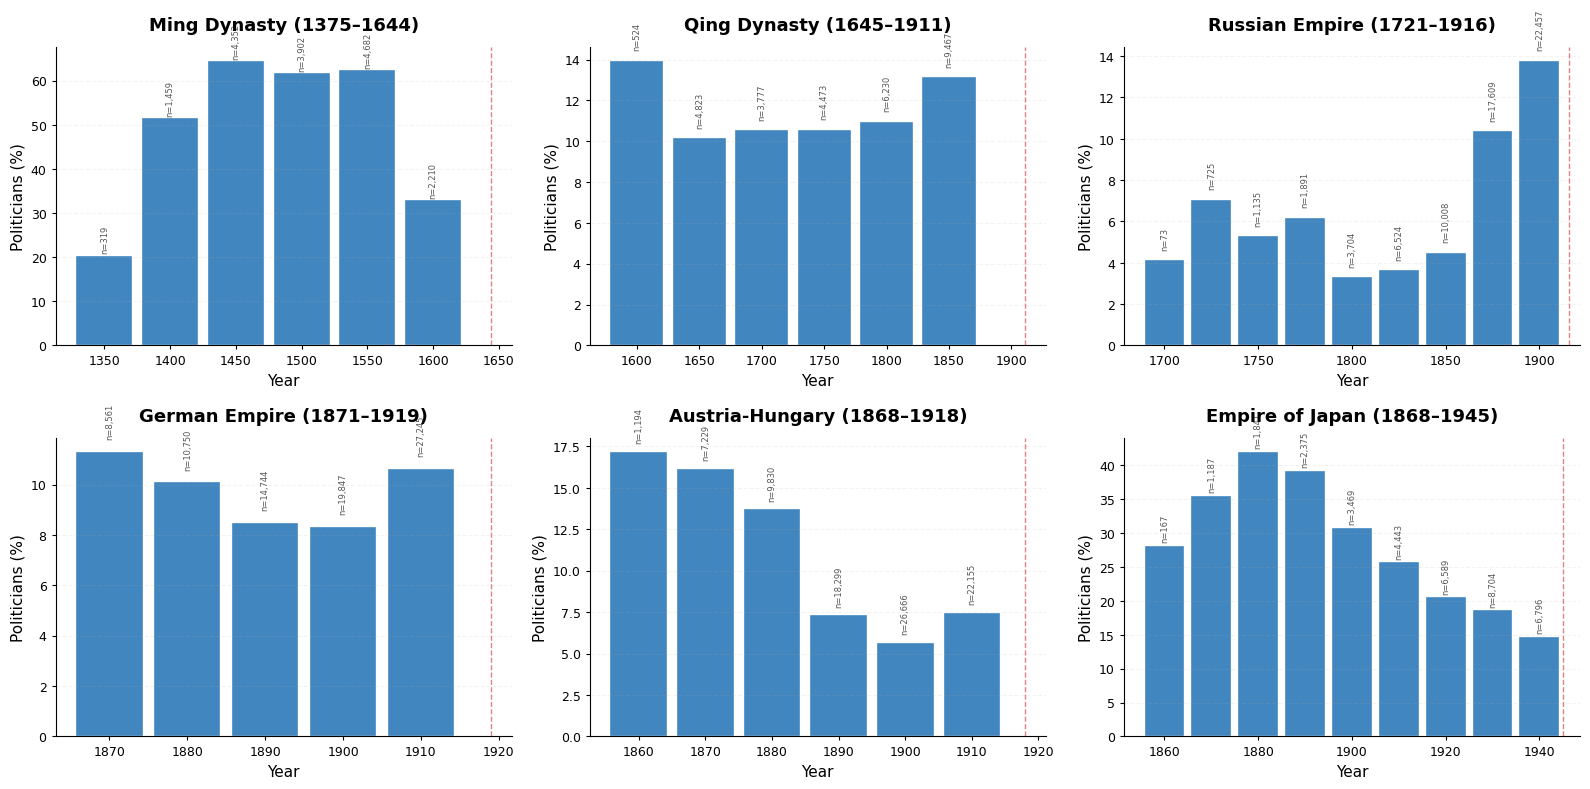

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

color = '#2171b5'

for idx, (label, yr_start, yr_end, bins, pcts, n_totals, bin_w) in enumerate(polity_data):
    ax = axes[idx]
    if not bins:
        ax.set_visible(False)
        continue

    ax.bar(bins, pcts, width=bin_w * 0.85, color=color,
           edgecolor='white', linewidth=0.3, alpha=0.85)

    # Annotate total individuals per bar (inside top of bar)
    for b, pct, n in zip(bins, pcts, n_totals):
        ax.text(b, pct + 0.5, f'n={n:,}', ha='center', va='bottom',
                fontsize=6, color='#555555', rotation=90)

    # Mark polity end
    ax.axvline(yr_end, color='#cc3333', linestyle='--', linewidth=1, alpha=0.6)

    ax.set_title(f"{label} ({yr_start}–{yr_end})", fontsize=13, fontweight='bold',
                 color='black', loc='center', pad=12)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Politicians (%)', fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='both', length=3, labelsize=9)
    ax.grid(axis='y', alpha=0.15, linestyle='--')

plt.tight_layout()
plt.show()

In [5]:
# --- Modern polities ---
conn2 = sqlite3.connect(DB)
conn2.execute('PRAGMA cache_size=-500000')

periods2 = conn2.execute('''
    SELECT DISTINCT polity_name, from_year, to_year
    FROM cliopatria_polity_periods ORDER BY polity_name, from_year
''').fetchall()
polity_periods2 = defaultdict(list)
for name, fr, to in periods2:
    polity_periods2[name].append((fr, to))

modern_selected = [
    ('United States',
     "ic.polity_name LIKE '%United States of America%'"),
    ('French Fifth Republic',
     "ic.polity_name = 'French Fifth Republic'"),
    ('USSR',
     "ic.polity_name LIKE '%Union of Soviet Socialist%'"),
    ('United Kingdom',
     "ic.polity_name LIKE '%Kingdom of Great Britain%'"),
    ('Republic of Indonesia',
     "ic.polity_name = 'Republic of Indonesia'"),
    ('German Democratic Republic',
     "ic.polity_name = 'German Democratic Republic'"),
]

# Use period from DB, with manual overrides for compound polity names
period_overrides = {
    'United States': (1776, 2024),
    'United Kingdom': (1709, 1999),
}

modern_data = []
for label, where in modern_selected:
    if label in period_overrides:
        yr_start, yr_end = period_overrides[label]
    else:
        # Try exact match first
        plist = polity_periods2.get(label, [])
        if plist:
            yr_start, yr_end = plist[0][0], plist[-1][1]
        else:
            # Fallback: get from data
            r = conn2.execute(f'''
                SELECT MIN(ic.impact_date), MAX(ic.impact_date)
                FROM individuals_cliopatria ic
                WHERE ({where}) AND ic.impact_date IS NOT NULL
            ''').fetchone()
            yr_start, yr_end = r[0], r[1]

    bin_w = 10

    pol_rows = conn2.execute(f'''
        SELECT (ic.impact_date / {bin_w}) * {bin_w} as time_bin,
               COUNT(DISTINCT ic.wikidata_id) as n
        FROM individuals_cliopatria ic
        JOIN individuals i ON ic.wikidata_id = i.wikidata_id
        WHERE ({where})
          AND i.occupations_en LIKE '%politician%'
          AND ic.impact_date IS NOT NULL
        GROUP BY time_bin
    ''').fetchall()
    pol_map = {r[0]: r[1] for r in pol_rows}

    tot_rows = conn2.execute(f'''
        SELECT (ic.impact_date / {bin_w}) * {bin_w} as time_bin,
               COUNT(DISTINCT ic.wikidata_id) as n
        FROM individuals_cliopatria ic
        WHERE ({where}) AND ic.impact_date IS NOT NULL
        GROUP BY time_bin
    ''').fetchall()
    tot_map = {r[0]: r[1] for r in tot_rows}

    # Drop partial last bucket
    last_full = (yr_end // bin_w) * bin_w
    if last_full > yr_end - bin_w // 2:
        last_full -= bin_w
    all_bins = sorted(set(list(pol_map.keys()) + list(tot_map.keys())))
    f_bins, f_pct, f_n = [], [], []
    for b in all_bins:
        if b >= (yr_start // bin_w) * bin_w and b <= last_full:
            total = tot_map.get(b, 0)
            pols = pol_map.get(b, 0)
            if total > 0:
                f_bins.append(b)
                f_pct.append(pols / total * 100)
                f_n.append(total)

    modern_data.append((label, yr_start, yr_end, f_bins, f_pct, f_n, bin_w))
    print(f"{label}: {yr_start}–{yr_end}, {len(f_bins)} bins")

conn2.close()

United States: 1776–2024, 25 bins


French Fifth Republic: 1958–2024, 7 bins


USSR: 1922–1991, 7 bins


United Kingdom: 1709–1999, 30 bins
Republic of Indonesia: 1946–2024, 8 bins


German Democratic Republic: 1949–1990, 5 bins


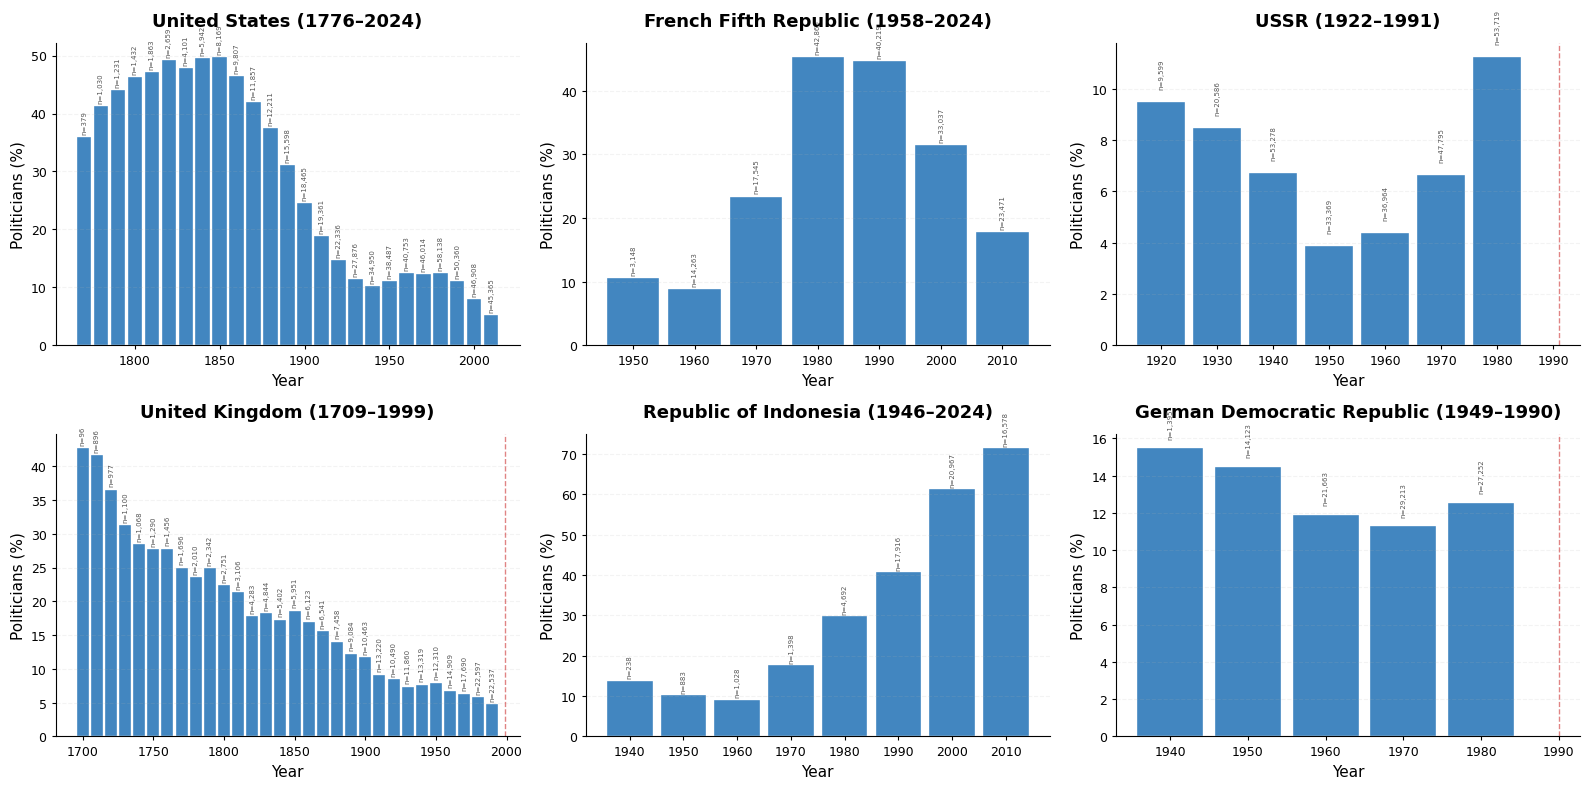

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

color = '#2171b5'

for idx, (label, yr_start, yr_end, bins, pcts, n_totals, bin_w) in enumerate(modern_data):
    ax = axes[idx]
    if not bins:
        ax.set_visible(False)
        continue

    ax.bar(bins, pcts, width=bin_w * 0.85, color=color,
           edgecolor='white', linewidth=0.3, alpha=0.85)

    for b, pct, n in zip(bins, pcts, n_totals):
        ax.text(b, pct + 0.5, f'n={n:,}', ha='center', va='bottom',
                fontsize=5, color='#555555', rotation=90)

    # Mark polity end if it ended before 2024
    if yr_end < 2020:
        ax.axvline(yr_end, color='#cc3333', linestyle='--', linewidth=1, alpha=0.6)

    ax.set_title(f"{label} ({yr_start}–{yr_end})", fontsize=13, fontweight='bold',
                 color='black', loc='center', pad=12)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Politicians (%)', fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='both', length=3, labelsize=9)
    ax.grid(axis='y', alpha=0.15, linestyle='--')

plt.tight_layout()
plt.show()